In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score



In [ ]:
from google.colab import files

uploaded = files.upload()

Saving star_classification.csv.zip to star_classification.csv.zip


In [ ]:
import zipfile

with zipfile.ZipFile('star_classification.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:

df = pd.read_csv("star_classification.csv")

df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [ ]:
# Convert class labels to numbers
le=LabelEncoder()
df['classs']=le.fit_transform(df['class'])



In [ ]:
X = df.drop([
    "class",
    "classs",   # VERY IMPORTANT
    "obj_ID",
    "run_ID",
    "rerun_ID",
    "cam_col",
    "field_ID",
    "spec_obj_ID"
], axis=1)
y=df['class']

In [ ]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
# DECISION TREE

dt = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred)

print("\nDecision Tree Accuracy:", accuracy)


Decision Tree Accuracy: 0.97595


In [51]:
# KNN


# Scale data for KNN and KMeans

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

pred = knn.predict(X_test_scaled)

knn_accuracy=accuracy_score(y_test, pred)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9271


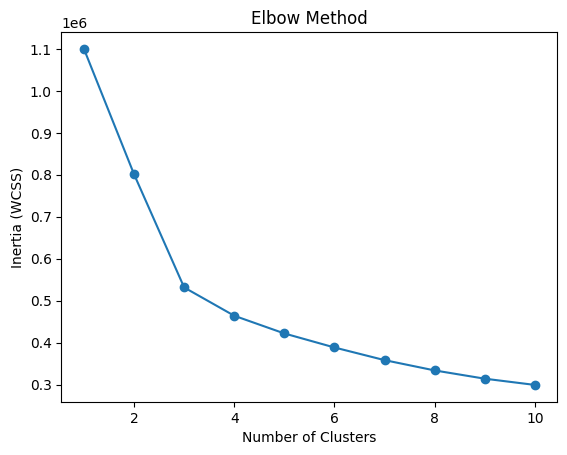

In [48]:
# KMeans

wcss = []

for i in range(1, 11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.show()

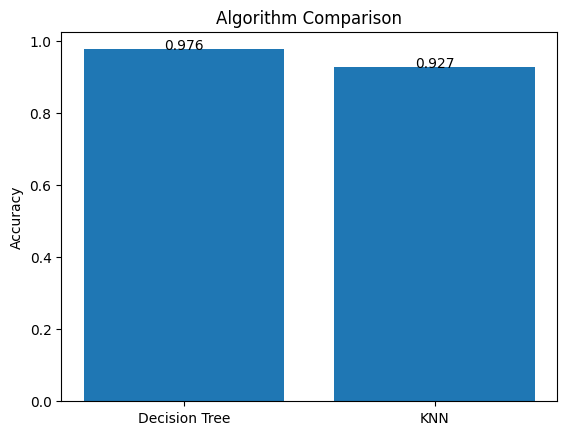

In [53]:
algorithms = ["Decision Tree", "KNN"]
scores = [dt_accuracy, knn_accuracy]

plt.bar(algorithms, scores)

plt.title("Algorithm Comparison")
plt.ylabel("Accuracy")
for i, score in enumerate(scores):
    plt.text(i, score, round(score, 3), ha='center')

plt.show()

# SUMMARY


**Decision Tree**


-Supervised learning algorithm

-creates tree like structure of decision rules based on feature values

-does not require feature scaling and easy to implement

-achieves high accuracy

**KNN**

-supervised learning algorithm that classifies a data point based on the majority class of its nearest neighbors

-relies heavily on distance calculations and therefore requires feature scaling using StandardScaler

-choice of the parameter K affects model performance and that KNN can become computationally expensive on large datasets because it must calculate distances to many training samples during prediction


**K-Means Clustering**

-unsupervised learning algorithm that groups data into clusters without using class labels

-assigns data points to the nearest centroid and iteratively updates cluster centers until convergence

-performance is evaluated using measures such as inertia and the elbow method rather than classification accuracy.


